<a href="https://colab.research.google.com/github/rifkaamandaputri17/24343046_RIFKA-AMANDA-PUTRI_TUGASMINGGU7_FREKUESIWAVALET/blob/main/tugas_7_frekuensi_wavalet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

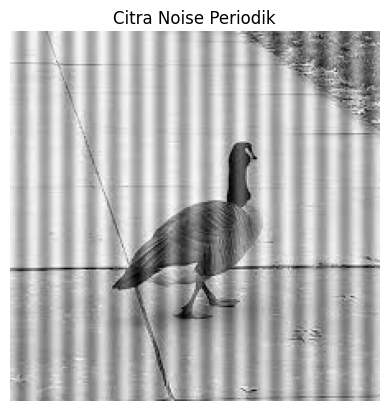

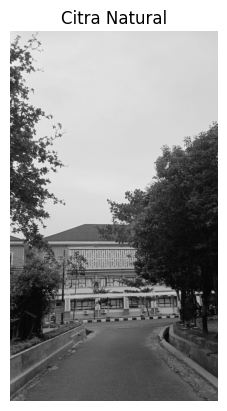

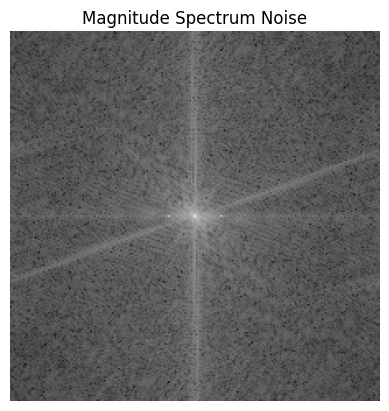

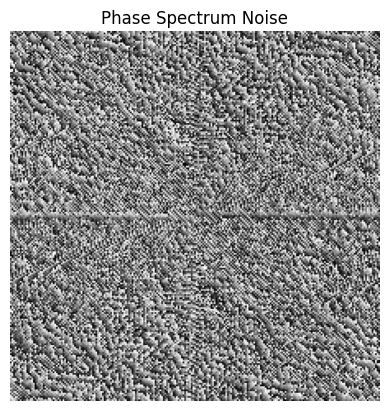

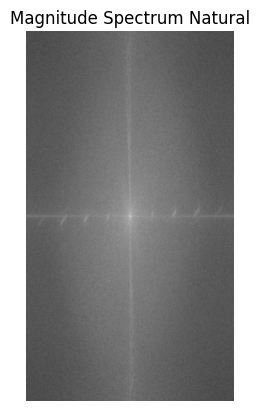

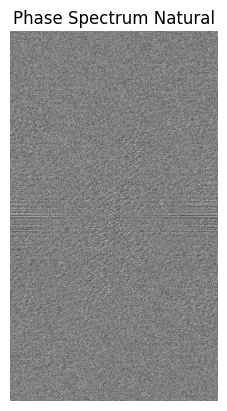

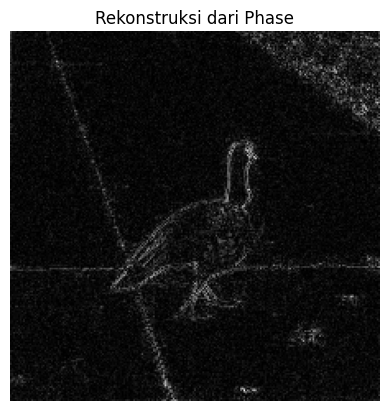

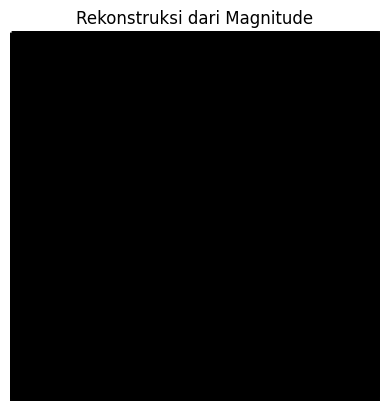

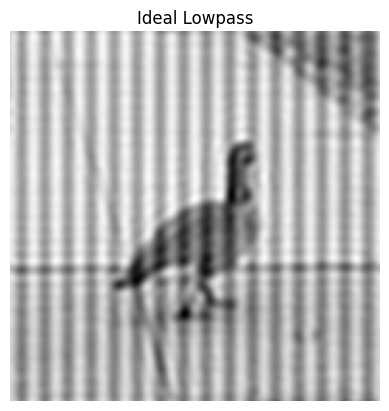

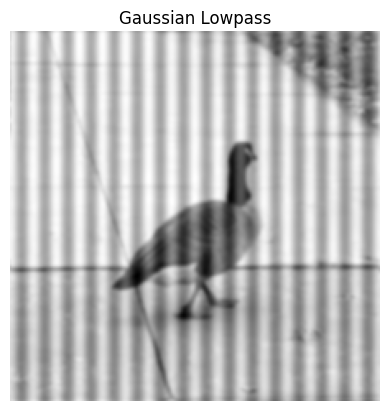

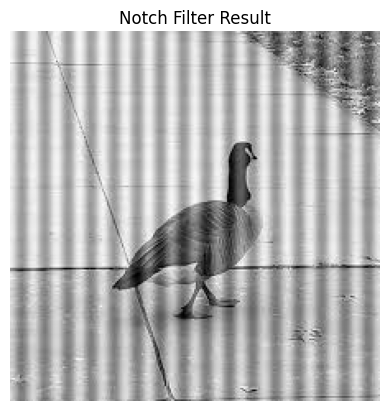

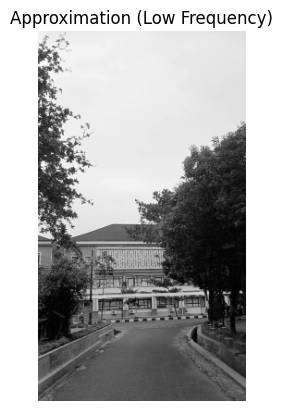

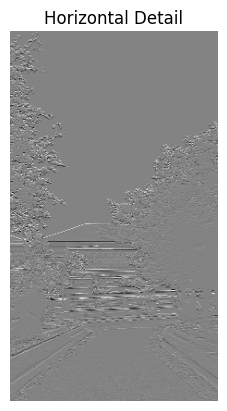

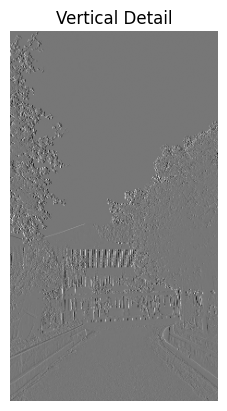

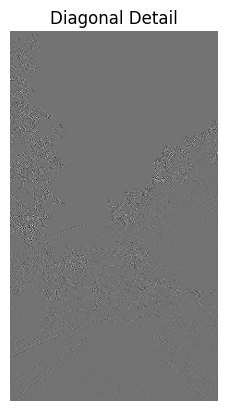

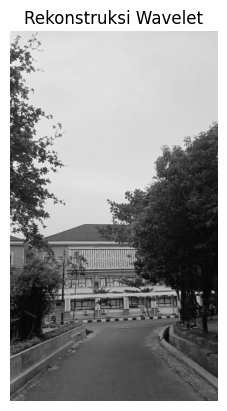

PSNR Notch Filter: 47.03746795102306
PSNR Gaussian Filter: 26.652589679784544


In [3]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt
from google.colab import files

img_noise = cv2.imread('noise.jpg', 0)
img_natural = cv2.imread('jalan.jpeg', 0)

# FUNGSI DISPLAY

def show(img, title):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

show(img_noise, "Citra Noise Periodik")
show(img_natural, "Citra Natural")


# FFT ANALYSIS

def fft_analysis(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(np.abs(fshift) + 1)
    phase = np.angle(fshift)
    return fshift, magnitude, phase

f_noise, mag_noise, phase_noise = fft_analysis(img_noise)
f_nat, mag_nat, phase_nat = fft_analysis(img_natural)

show(mag_noise, "Magnitude Spectrum Noise")
show(phase_noise, "Phase Spectrum Noise")
show(mag_nat, "Magnitude Spectrum Natural")
show(phase_nat, "Phase Spectrum Natural")


# REKONSTRUKSI

def reconstruct(magnitude, phase):
    complex_img = magnitude * np.exp(1j * phase)
    img_back = np.fft.ifft2(np.fft.ifftshift(complex_img))
    return np.abs(img_back)

# Phase only
phase_only = reconstruct(np.ones_like(mag_noise), phase_noise)

# Magnitude only
mag_only = reconstruct(mag_noise, np.zeros_like(phase_noise))

show(phase_only, "Rekonstruksi dari Phase")
show(mag_only, "Rekonstruksi dari Magnitude")


# IDEAL LOWPASS FILTER

def ideal_lowpass(fshift, cutoff):
    rows, cols = fshift.shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            if (i-crow)**2 + (j-ccol)**2 <= cutoff**2:
                mask[i,j] = 1

    filtered = fshift * mask
    img_back = np.fft.ifft2(np.fft.ifftshift(filtered))
    return np.abs(img_back)

lp_img = ideal_lowpass(f_noise, 30)
show(lp_img, "Ideal Lowpass")

# GAUSSIAN LOWPASS FILTER
def gaussian_lowpass(fshift, sigma):
    rows, cols = fshift.shape
    x = np.linspace(-cols//2, cols//2, cols)
    y = np.linspace(-rows//2, rows//2, rows)
    X, Y = np.meshgrid(x, y)

    d = np.sqrt(X**2 + Y**2)
    mask = np.exp(-(d**2)/(2*(sigma**2)))

    filtered = fshift * mask
    img_back = np.fft.ifft2(np.fft.ifftshift(filtered))
    return np.abs(img_back)

gauss_img = gaussian_lowpass(f_noise, 30)
show(gauss_img, "Gaussian Lowpass")


# NOTCH FILTER (UNTUK NOISE PERIODIK)

def notch_filter(fshift):
    rows, cols = fshift.shape
    crow, ccol = rows//2, cols//2

    mask = np.ones((rows, cols))

    # titik noise (adjust jika perlu)
    mask[crow+20, ccol] = 0
    mask[crow-20, ccol] = 0

    filtered = fshift * mask
    img_back = np.fft.ifft2(np.fft.ifftshift(filtered))
    return np.abs(img_back)

notch_img = notch_filter(f_noise)
show(notch_img, "Notch Filter Result")

# WAVELET TRANSFORM (2 LEVEL)

coeffs = pywt.wavedec2(img_natural, 'haar', level=2)

cA, (cH, cV, cD), (cH2, cV2, cD2) = coeffs

show(cA, "Approximation (Low Frequency)")
show(cH, "Horizontal Detail")
show(cV, "Vertical Detail")
show(cD, "Diagonal Detail")


# REKONSTRUKSI WAVELET

recon_wavelet = pywt.waverec2(coeffs, 'haar')
show(recon_wavelet, "Rekonstruksi Wavelet")

# PSNR EVALUATION
def psnr(original, compressed):
    mse = np.mean((original - compressed) ** 2)
    return 20 * np.log10(255 / np.sqrt(mse))

print("PSNR Notch Filter:", psnr(img_noise, notch_img))
print("PSNR Gaussian Filter:", psnr(img_noise, gauss_img))